# Independence Weight Sweep

Visualises how Barlow Twins score on Ant-medium-v2 varies with `indep_weight`,
demonstrating that the original value (tuned on HalfCheetah) is overly large
for Ant's higher-dimensional latent space.

In [6]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Cannot locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import RAW_METRICS_DIR, FIGURES_INDEP_SWEEP_DIR

print(f"PROJECT_ROOT         = {PROJECT_ROOT}")
print(f"FIGURES_INDEP_SWEEP_DIR = {FIGURES_INDEP_SWEEP_DIR}")

PROJECT_ROOT         = /home/wyuhan/projects/robust-offline-rl-disentanglement
FIGURES_INDEP_SWEEP_DIR = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/indep_sweep/figures


In [ ]:
# config
METHOD       = "disentangled_barlow_indep_sweep"
ENV_NAME     = "ant-medium-v2"
NOISE_DIM    = 83
NOISE_SCALE  = 1.0
NOISE_TYPE   = "nonlinear"
SEEDS        = [1]          # extend once more seeds are available

# Reference baselines at the same (env, noise_dim, noise_scale, seed)
BASELINE_METHODS = {
    "plain":               "Plain Encoder",
    "raw_noisy":           "Raw Noisy",
    "disentangled_barlow": "Barlow (original iw=0.05)",
}

ORIG_IW   = 0.05    # value used in main experiment
SAVE_FIG  = True
SHOW_FIG  = True

In [ ]:
# Load sweep results 
ns_tag = str(NOISE_SCALE).replace(".", "p")
sweep_dir = (
    RAW_METRICS_DIR / METHOD / METHOD
    / ENV_NAME / f"nd{NOISE_DIM}_ns{ns_tag}_{NOISE_TYPE}"
)

records = []
for seed in SEEDS:
    seed_dir = sweep_dir / f"seed_{seed}"
    if not seed_dir.exists():
        print(f"[WARN] seed dir not found: {seed_dir}")
        continue
    for iw_dir in seed_dir.iterdir():
        fp = iw_dir / "metrics.json"
        if not fp.exists():
            continue
        data = json.loads(fp.read_text())
        records.append({
            "iw":    float(data["indep_weight"]),
            "score": float(data["normalized_score"]),
            "seed":  seed,
        })

if not records:
    raise RuntimeError("No sweep records found. Check METHOD / ENV_NAME / paths.")

# Aggregate across seeds: mean ± std per iw
from collections import defaultdict
iw_to_scores = defaultdict(list)
for r in records:
    iw_to_scores[r["iw"]].append(r["score"])

iw_vals    = sorted(iw_to_scores.keys())
mean_vals  = [np.mean(iw_to_scores[iw]) for iw in iw_vals]
std_vals   = [np.std(iw_to_scores[iw], ddof=0) for iw in iw_vals]
n_per_iw   = [len(iw_to_scores[iw]) for iw in iw_vals]

print(f"Loaded {len(records)} records across {len(SEEDS)} seed(s)")
print(f"  iw range    : {min(iw_vals):.4f} – {max(iw_vals):.4f}")
print(f"  score range : {min(mean_vals):.2f} – {max(mean_vals):.2f}  (mean)")
print(f"  seeds per iw: {set(n_per_iw)}")

Loaded 14 records across 1 seed(s)
  iw range    : 0.0005 – 0.1500
  score range : -1.67 – 75.61  (mean)
  seeds per iw: {1}


In [ ]:
# Load baselines 
baseline_scores = {}
for method, label in BASELINE_METHODS.items():
    scores = []
    for seed in SEEDS:
        fp = (
            RAW_METRICS_DIR / method / ENV_NAME
            / f"nd{NOISE_DIM}_ns{ns_tag}_{NOISE_TYPE}"
            / f"seed_{seed}" / "metrics.json"
        )
        if fp.exists():
            scores.append(float(json.loads(fp.read_text())["normalized_score"]))
    if scores:
        baseline_scores[label] = np.mean(scores)
        print(f"{label:35s}: {baseline_scores[label]:.2f}")
    else:
        print(f"{label:35s}: NOT FOUND")

Plain Encoder                      : 69.38
Raw Noisy                          : 72.03
Barlow (original iw=0.05)          : 5.16


Saved → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/indep_sweep/figures/ant-medium-v2/barlow_indep_weight_sweep.pdf


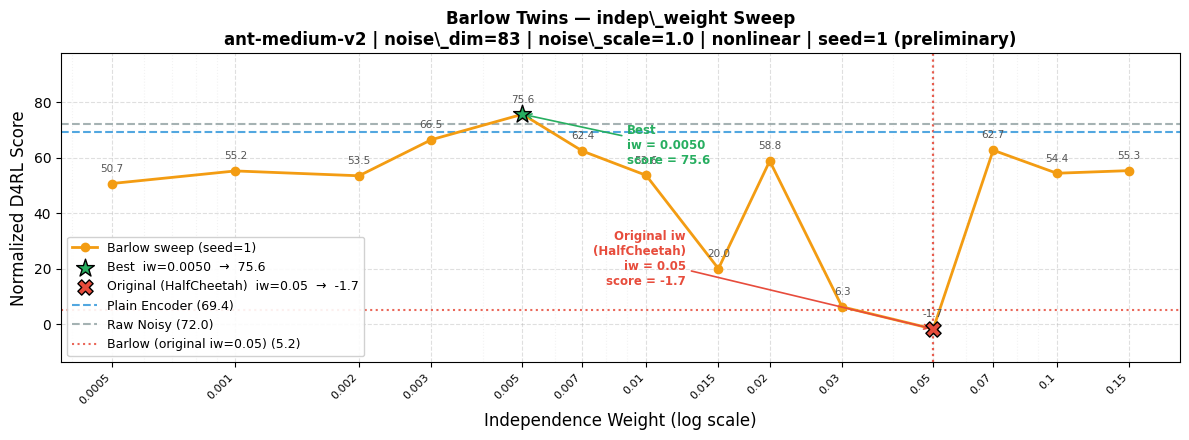

In [ ]:
# Plot 
BASELINE_STYLE = {
    "Plain Encoder":             {"color": "#3498db", "ls": "--", "lw": 1.5},
    "Raw Noisy":                 {"color": "#95a5a6", "ls": "--", "lw": 1.5},
    "Barlow (original iw=0.05)": {"color": "#e74c3c", "ls": ":",  "lw": 1.5},
}

n_seeds = len(SEEDS)
seed_label = f"seed={SEEDS[0]}" if n_seeds == 1 else f"mean ± std  ({n_seeds} seeds)"

fig, ax = plt.subplots(figsize=(12, 4.5))

mean_arr = np.array(mean_vals)
std_arr  = np.array(std_vals)

# Mean line 
ax.plot(iw_vals, mean_arr,
        marker="o", markersize=6, linewidth=2,
        color="#f39c12", label=f"Barlow sweep ({seed_label})", zorder=3)

# Std shading (invisible when n_seeds == 1)
if n_seeds > 1:
    ax.fill_between(iw_vals,
                    mean_arr - std_arr,
                    mean_arr + std_arr,
                    alpha=0.20, color="#f39c12", zorder=2)

# Score labels above every point
for iw, mean, std in zip(iw_vals, mean_arr, std_arr):
    label_text = f"{mean:.1f}" if n_seeds == 1 else f"{mean:.1f}±{std:.1f}"
    ax.annotate(
        label_text,
        xy=(iw, mean),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=7.5, color="#555555",
    )

# Best point (star marker + bold annotation)
best_idx   = int(np.argmax(mean_arr))
best_iw    = iw_vals[best_idx]
best_mean  = mean_arr[best_idx]
best_std   = std_arr[best_idx]
best_label = f"{best_mean:.1f}" if n_seeds == 1 else f"{best_mean:.1f}±{best_std:.1f}"

ax.scatter([best_iw], [best_mean], s=180, zorder=5,
           marker="*", color="#27ae60", edgecolors="black", linewidth=1.0,
           label=f"Best  iw={best_iw:.4f}  →  {best_label}")
ax.annotate(
    f"Best\niw = {best_iw:.4f}\nscore = {best_label}",
    xy=(best_iw, best_mean),
    xytext=(best_iw * 1.8, best_mean - 18),
    fontsize=8.5, ha="left", color="#27ae60", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.2),
)

# Original iw (vertical line + marker + annotation)
if ORIG_IW in iw_vals:
    orig_idx   = iw_vals.index(ORIG_IW)
    orig_mean  = mean_arr[orig_idx]
    orig_std   = std_arr[orig_idx]
    orig_label = f"{orig_mean:.1f}" if n_seeds == 1 else f"{orig_mean:.1f}±{orig_std:.1f}"

    ax.axvline(ORIG_IW, color="#e74c3c", linestyle=":", linewidth=1.6, alpha=0.9, zorder=2)
    ax.scatter([ORIG_IW], [orig_mean], s=120, zorder=5,
               marker="X", color="#e74c3c", edgecolors="black", linewidth=1.0,
               label=f"Original (HalfCheetah)  iw={ORIG_IW}  →  {orig_label}")
    ax.annotate(
        f"Original iw\n(HalfCheetah)\niw = {ORIG_IW}\nscore = {orig_label}",
        xy=(ORIG_IW, orig_mean),
        xytext=(ORIG_IW * 0.25, orig_mean + 16),
        fontsize=8.5, ha="right", color="#e74c3c", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.2),
    )

# Baseline horizontal lines
for label, score in baseline_scores.items():
    style = BASELINE_STYLE.get(label, {"color": "gray", "ls": "--", "lw": 1.2})
    ax.axhline(score, label=f"{label} ({score:.1f})",
               color=style["color"], linestyle=style["ls"],
               linewidth=style["lw"], alpha=0.85)

# Axes
ax.set_xscale("log")
ax.set_xlabel("Independence Weight (log scale)", fontsize=12)
ax.set_ylabel("Normalized D4RL Score", fontsize=12)
ax.set_title(
    f"Barlow Twins — indep\\_weight Sweep\n"
    f"{ENV_NAME} | noise\\_dim={NOISE_DIM} | noise\\_scale={NOISE_SCALE} | {NOISE_TYPE}"
    + (f" | {n_seeds} seeds" if n_seeds > 1 else " | seed=1 (preliminary)"),
    fontsize=12, fontweight="bold",
)

ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticks(iw_vals)
ax.get_xaxis().set_tick_params(which="minor", size=0)
ax.set_xticklabels([str(v) for v in iw_vals], rotation=45, ha="right", fontsize=8)

ax.grid(True, which="major", linestyle="--", alpha=0.4)
ax.grid(True, which="minor", linestyle=":",  alpha=0.15)

all_scores = list(mean_arr) + list(baseline_scores.values())
ymin = min(all_scores) - 12
ymax = max(all_scores) + 22
ax.set_ylim(ymin, ymax)

ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
plt.tight_layout()

if SAVE_FIG:
    out = FIGURES_INDEP_SWEEP_DIR / ENV_NAME / "barlow_indep_weight_sweep.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved → {out}")

if SHOW_FIG:
    plt.show()
else:
    plt.close()